In [4]:
import pandas as pd
import numpy as np
import seaborn as sns

In [5]:
df=pd.read_csv("emo_detect.csv")


In [6]:
df['emotion'].value_counts()

emotion
joy        15000
sad        15000
fear        7500
love        7500
anger       7500
suprise     7500
Name: count, dtype: int64

<Axes: xlabel='emotion', ylabel='count'>

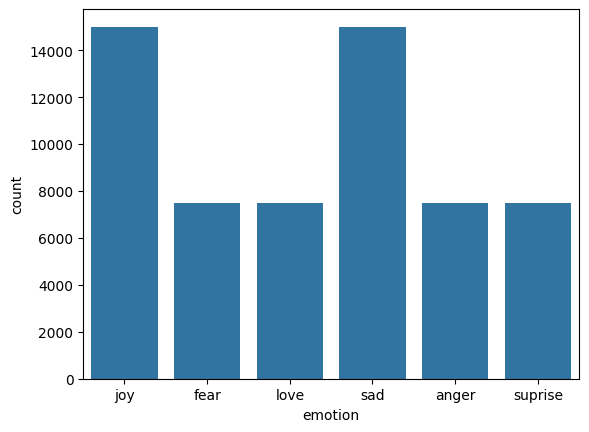

In [7]:
sns.countplot(x='emotion',data=df)

In [8]:
import neattext as nfx

In [9]:
df['clean_text']=df['text'].apply(nfx.remove_userhandles)

In [10]:
dir(nfx)

['AUTOMATED_READ_INDEX',
 'BTC_ADDRESS_REGEX',
 'CONTRACTIONS_DICT',
 'CURRENCY_REGEX',
 'CURRENCY_SYMB_REGEX',
 'Callable',
 'Counter',
 'CreditCard_REGEX',
 'DATE_REGEX',
 'EMAIL_REGEX',
 'EMOJI_REGEX',
 'FUNCTORS_WORDLIST',
 'HASTAG_REGEX',
 'HTML_TAGS_REGEX',
 'List',
 'MASTERCard_REGEX',
 'MD5_SHA_REGEX',
 'MOST_COMMON_PUNCT_REGEX',
 'NUMBERS_REGEX',
 'PHONE_REGEX',
 'PUNCT_REGEX',
 'PoBOX_REGEX',
 'SPECIAL_CHARACTERS_REGEX',
 'STOPWORDS',
 'STOPWORDS_de',
 'STOPWORDS_en',
 'STOPWORDS_es',
 'STOPWORDS_fr',
 'STOPWORDS_ru',
 'STOPWORDS_yo',
 'STREET_ADDRESS_REGEX',
 'TextCleaner',
 'TextExtractor',
 'TextFrame',
 'TextMetrics',
 'TextPipeline',
 'Tuple',
 'URL_PATTERN',
 'USER_HANDLES_REGEX',
 'VISACard_REGEX',
 'ZIP_REGEX',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'clean_text',
 'defaultdict',
 'digit2words',
 'emoji_explainer',
 'emojify',
 'explainer',
 'extract_btc_address',
 

In [11]:
df['clean_text']=df['clean_text'].apply(nfx.remove_stopwords)

In [12]:
df

,sl.no,emotion,text,clean_text
0,1,joy,i paid euros for something i already felt belo...,paid euros felt belonged soul feel convinced g...
1,2,fear,i was feeling a little strange so i decided to...,feeling little strange decided lie rest bit
2,3,fear,i feel scared and lonely,feel scared lonely
3,4,joy,im feeling superbly generous a dress for miss ...,im feeling superbly generous dress miss rosey ...
4,5,joy,i know that there are other factors that influ...,know factors influence students passivity clas...
...,...,...,...,...
59995,59996,suprise,i love this weather i think its made today fee...,love weather think today feel strange
59996,59997,fear,i fod a couple of my entries because all of a ...,fod couple entries sudden im feeling skeptical
59997,59998,joy,i am on some nice meds to hopefully start maki...,nice meds hopefully start making feel better
59998,59999,sad,i didn t of course because if it didn t feel a...,course feel awkward sure hell


In [13]:
x=df['clean_text']
y=df['emotion']

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [16]:
from sklearn.pipeline import Pipeline

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

In [18]:
from sklearn.svm import SVC

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
pipe_lr=Pipeline(steps=[('cv',CountVectorizer()),('lr',LogisticRegression())])
pipe_lr.fit(x_train,y_train)
pipe_lr.score(x_test,y_test)


C:\Users\VICTUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9001111111111111

In [19]:
pipe_rf=Pipeline(steps=[('cv',CountVectorizer()),('rf',RandomForestClassifier(n_estimators=10))])
pipe_rf.fit(x_train,y_train)
pipe_rf.score(x_test,y_test)

0.8801111111111111

In [20]:
from sklearn.svm import LinearSVC

In [21]:
pipe_svm = Pipeline(steps=[('cv', CountVectorizer()), ('svc', LinearSVC(C=1.0))])

In [26]:
import joblib


In [27]:
joblib.dump(pipe_svm, "text_emo.pkl")

['text_emo.pkl']

In [28]:
print("Model saved successfully as text_emotion_svm.pkl")

Model saved successfully as text_emotion_svm.pkl


In [23]:
from sklearn.metrics import classification_report

y_preds = pipe_svm.predict(x_test)
print(classification_report(y_test, y_preds))

NotFittedError: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [24]:
pipe_svm.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cv', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [25]:
y_preds = pipe_svm.predict(x_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

       anger       0.91      0.90      0.90      2268
        fear       0.85      0.83      0.84      2245
         joy       0.91      0.89      0.90      4504
        love       0.85      0.89      0.87      2185
         sad       0.93      0.92      0.92      4499
     suprise       0.87      0.93      0.90      2299

    accuracy                           0.89     18000
   macro avg       0.89      0.89      0.89     18000
weighted avg       0.89      0.89      0.89     18000



In [29]:
import joblib
model = joblib.load("text_emo.pkl")
model.predict(["I feel great!"])


array(['sad'], dtype=object)